#### **Import Library**

In [22]:
import numpy as np
import pandas as pd 
import time
import requests
import json
from scipy.stats import rankdata
import pandas as pd
import csv
import math
import pdb
import datetime
from tqdm import tqdm
from sklearn.linear_model import LinearRegression 

import akshare as ak
import mplfinance as mpf
import matplotlib.pyplot as plt 
from scipy.optimize import minimize

import warnings 
warnings.filterwarnings("ignore")

sd = "20180101"
ed = str(datetime.datetime.today())[:10].replace("-", "")
uv_size = 6566

#### **Define Util Functions**

In [23]:
# normalization: scaling and normalization ===========================================
def normalization_clip(np_arr):
    return np.clip(np_arr, -1, 1)

def normalization_zscore(np_arr):
    mean = np.mean(np_arr)  
    std = np.std(np_arr)  
    zscore_normalized_data = (np_arr - mean) / std 
    return zscore_normalized_data

def normalization_scale(arr):  
    # arr = util_nan_inf(arr)
    min_val = np.nanmin(arr)  
    max_val = np.nanmax(arr)  
    scaled_arr = 2 * (arr - min_val) / (max_val - min_val) - 1  
    return scaled_arr 

# ML: machine learning aux functions ===========================================
def ML_LR_daily(np_X, np_Y, di = 0, plot = False):
    np_X_reshaped = np_X.reshape(-1, 1)
    model = LinearRegression()
    model.fit(np_X_reshaped, np_Y) 
    np_Y_predicted = model.predict(np_X_reshaped)  
    residuals = np_Y - np_Y_predicted
    if plot == True:
        plot_LR(np_X, np_Y, model.coef_, model.intercept_, di)
    return [residuals, model.coef_, model.intercept_]

def ML_LR_diy(np_X, np_Y, di = 0, plot = False): # 自定义损失函数
    def custom_loss_function(params, X, y):
        slope, intercept = params
        y_pred = slope * X + intercept
        # loss = np.sum(np.log(y_pred) * (y_pred - y)**2 )
        loss = np.sum(y * (np.log(y) - np.log(y_pred))) # "similar" to pointwise KL divergence 
        return loss

    def fit_model_with_custom_loss(X, y):
        initial_params = [0.0, 0.0]
        result = minimize(custom_loss_function, initial_params, args=(X, y))
        slope, intercept = result.x
        y_pred = slope * X + intercept
        residuals = y - y_pred
        return residuals, slope, intercept
    residuals, slope, intercept = fit_model_with_custom_loss(np_X, np_Y)
    return [residuals, slope, intercept]

def ML_distance(X, Y, di = 0, plot = False):  
    x_mean = np.mean(X)  
    y_mean = np.mean(Y)  
      
    distances_squared = (X - x_mean)**2 + (Y - y_mean)**2  
      
    total_distance_squared = np.sum(distances_squared)  
      
    return [distances_squared, [x_mean, y_mean], total_distance_squared]

def ML_MLP_ndim(lst_np_arr_X, np_arr_Y):
    pass

# utilities: manipulation on several given values===========================================
def util_nan_inf(np_arr, eps = 0.0):
    return np.nan_to_num(np_arr, nan = eps, posinf = 1000, neginf = -1000)

def util_std_outlier(np_arr, n = 3):
    np_std = np_arr
    mean = np.mean(np_std)  
    std_dev = np.std(np_std)  
    upper_limit = mean + n * std_dev  
    lower_limit = mean - n * std_dev  
    np_std[np_std > upper_limit] = upper_limit  
    np_std[np_std < lower_limit] = lower_limit 
    return np_std

# functions: manipulation on most given values===========================================
def func_sigmoid(np_arr):
    return 1 / (1 + np.exp(-np_arr))

def func_softmax(np_arr):
    return np.exp(np_arr) / np.sum(np.exp(np_arr))

def func_tanh(np_arr):
    return (np.exp(np_arr) - np.exp(-np_arr)) / (np.exp(np_arr) + np.exp(np_arr))

def func_relu(np_arr):
    return np.where(np_arr < 0, 0, np_arr)

def func_rank(np_arr):
    return rankdata(np_arr, nan_policy = "omit")

# functions: manipulation on most given values=========================================== 
  
def plot_LR(X, Y, coef, intercept, di = "", output_file='_linear_regression_plot.png'):  
    X[X < 0] = 0 # nan的很多数据被标为了极大的负值
    print([coef, intercept])
    fig, ax = plt.subplots()  
    ax.scatter(X, Y, label='Original Data', color='blue')  
       
    X_line = np.linspace(np.min(X), np.max(X), 100)  
    Y_line = coef * X_line + intercept  
    ax.plot(X_line, Y_line, color='red', label='Regression Line')  
    
    ax.legend()  
    ax.set_title('Linear Regression Plot')  
    ax.set_xlabel('X')  
    ax.set_ylabel('Y')  
      
    plt.savefig("./plotting/" + str(di) + output_file)  
    plt.close(fig) 
    print(f"Plot saved as {output_file}") 

def plot_visualization(X, Y):
    plt.scatter(X, Y)  
    plt.title('Title')  
    plt.xlabel('X')  
    plt.ylabel('Y')  
     
    plt.savefig('./plot_visualization.png', dpi=300)

def util_smooth(di, para):  
    # print(di)
    results = []  
    for i in range(para.shape[1]):  
        current_value = para[di, i]
        target_value = para[di, i]  
        # search forward
        prev_diff_value = None  
        prev_diff_index = None  
        for j in range(di-1, -1, -1):  
            if para[j, i] != target_value:  
                prev_diff_value = para[j, i]  
                prev_diff_index = j  
                break  
        # search backward
        next_diff_value = None  
        next_diff_index = None  
        for j in range(di+1, para.shape[0]):  
            if para[j, i] != target_value:  
                next_diff_value = para[j, i]  
                next_diff_index = j  
                break    
        if (current_value == np.nan) or (current_value == None):
          result = (prev_diff_value + next_diff_value) / 2
        elif (prev_diff_index == None) or (prev_diff_index == np.nan) or (next_diff_value == None) or (next_diff_value == np.nan) or (next_diff_index == np.nan) or (next_diff_index == None):
          result = current_value
        else:
          result = current_value + (next_diff_value - current_value) * (di - prev_diff_index) / (next_diff_index - prev_diff_index)
        results.append(result)
    return np.array(results[:uv_size])

class KalmanFilter:  
    def __init__(self, process_variance, measurement_variance, estimated_error):  
        self.process_variance = process_variance  # 过程噪声的协方差 
        self.measurement_variance = measurement_variance  # 测量噪声的协方差  
        self.estimated_error = estimated_error  # 估计误差的协方差  
        self.kalman_gain = 0.0  
  
    def filter(self, measurements):  
        num_days, num_stocks = measurements.shape  
        estimates = np.zeros_like(measurements)  
          
        for stock_idx in range(num_stocks):  
            self.current_estimate = 0.0  
            self.last_estimate = 0.0  
              
            for day_idx in range(num_days):  
                measurement = measurements[day_idx, stock_idx]  
                  
                # update parameters
                self.kalman_gain = self.estimated_error / (self.estimated_error + self.measurement_variance)  
                self.current_estimate = self.last_estimate + self.kalman_gain * (measurement - self.last_estimate)   
                self.estimated_error = (1 - self.kalman_gain) * self.estimated_error + self.process_variance  
                self.last_estimate = self.current_estimate  
                estimates[day_idx, stock_idx] = self.current_estimate  
          
        return estimates
    
def stock_constraint_func():
    kechuang = ak.stock_kc_a_spot_em().iloc[:, 1].astype(str).to_list()
    ST_risk = ak.stock_zh_a_st_em().iloc[:, 1].astype(str).to_list()
    beijing_A = ak.stock_bj_a_spot_em().iloc[:, 1].astype(str).to_list()
    kechuang_02 = ak.stock_cy_a_spot_em().iloc[:, 1].astype(str).to_list()
    return kechuang + ST_risk + beijing_A + kechuang_02

stock_constraint = stock_constraint_func()

#### **Industry and Concept neutralization**

In [24]:
# pending ...
# stock_fund_flow_concept_df = ak.stock_fund_flow_concept(symbol="即时")
# stock_fund_flow_industry_df = ak.stock_fund_flow_industry(symbol="即时")

#### **Alphas**

In [25]:
# read files
tickers_code = pd.read_csv('database/tickers_code.csv', dtype = str).iloc[:, 0].to_list()
tickers_name = pd.read_csv('database/tickers_name.csv', dtype = str).iloc[:, 0].to_list()

data_open = pd.read_csv("./database/data_open.csv").to_numpy()
data_close = pd.read_csv("./database/data_close.csv").to_numpy()
data_high = pd.read_csv("./database/data_high.csv").to_numpy()
data_low = pd.read_csv("./database/data_low.csv").to_numpy()
data_vol = pd.read_csv("./database/data_vol.csv").to_numpy()
data_val = pd.read_csv("./database/data_val.csv").to_numpy()
data_tvr = pd.read_csv("./database/data_tvr.csv").to_numpy()
data_vwap = pd.read_csv("./database/data_vwap.csv").to_numpy()

data_pe_ttm = pd.read_csv("./database/data_pe_ttm.csv").to_numpy()
data_pb = pd.read_csv("./database/data_pb.csv").to_numpy()
data_roe_qfa = pd.read_csv("./database/data_roe_qfa.csv").to_numpy()

data_curr_ratio = pd.read_csv("./database/data_curr_ratio.csv").to_numpy()
data_curr_diffhold = pd.read_csv("./database/data_curr_diffhold.csv").to_numpy()


# define alphas
def Alpha_pbroe(di):
  # di -= 1
  # alpha1 = 1/ (self.pb[di, :uv.Instruments.size()] / (self.roe_qfa[di, :uv.Instruments.size()]) ** 2)
  # alpha2 = (abs(self.roe_qfa[di, :uv.Instruments.size()]) / self.roe_qfa[di, :uv.Instruments.size()]) * 1/(self.pb[di, :uv.Instruments.size()] / (self.roe_qfa[di, :uv.Instruments.size()]) ** 2)
  # alpha3 = (self.roe_qfa[di, :uv.Instruments.size()] / self.roe_qfa[di, :uv.Instruments.size()]) * 1/(self.pb[di, :uv.Instruments.size()] / (self.roe_qfa[di, :uv.Instruments.size()]))
  # try:  
  #     df = pd.read_csv('roe_smooth.csv', header=None)  
  # except FileNotFoundError:  
  #     df = pd.DataFrame()   
  # df = df.append(pd.Series(roe_smooth), ignore_index=True)  
  # df.to_csv('roe_smooth.csv', index=False, header=False)
  # roe_smooth = pd.read_csv("roe_smooth.csv").iloc[di - 1713, :].to_numpy()
  
  # stage 2:
  # roe_smooth = self.smooth(di)
  # alpha4 = (abs(roe_smooth) / roe_smooth) * 1/(self.pb[di, :uv.Instruments.size()] / (roe_smooth) ** 2)
  # alpha5 = (abs(roe_smooth) / roe_smooth) * 1/(self.pb[di, :uv.Instruments.size()] / (roe_smooth) ** 2) - (abs(self.con_roe[di, :uv.Instruments.size()]) / self.con_roe[di, :uv.Instruments.size()]) * 1/(self.con_pb[di, :uv.Instruments.size()] / (self.con_roe[di, :uv.Instruments.size()])) # 0.26
  # con_roe_smooth = self.con_smooth(di, 60)
  # alpha6 = (abs(roe_smooth) / roe_smooth) * 1/(self.pb[di, :uv.Instruments.size()] / (roe_smooth) ** 2) - 1/(self.con_pb[di-60, :uv.Instruments.size()] / abs(con_roe_smooth)) # 0.31
  
  # stage 3:
  roe_smooth = util_smooth(di, data_roe_qfa)
  ln_ROE = np.nan_to_num((roe_smooth), nan=0.0, posinf=10000, neginf=-10000)  # the target value of inf doesn't really matter
  ln_PB = np.nan_to_num((data_pb[di, :]), nan=0.0, posinf=10000, neginf=-10000)  
  ln_PB_reshaped = ln_PB.reshape(-1, 1)  
  model = LinearRegression()  
  model.fit(ln_PB_reshaped, ln_ROE)  
  ln_ROE_predicted = model.predict(ln_PB_reshaped)  
  residuals = ln_ROE - ln_ROE_predicted
  alpha = residuals
  return alpha

def Alpha_peroe(di):
  # di -= 1

  # alpha1 = 1/ (self.pe_ttm[di, :uv.Instruments.size()] / ( self.roe_qfa[di, :uv.Instruments.size()])) - 1/ (self.pe_ttm[di-3, :uv.Instruments.size()] / ( self.roe_qfa[di-3, :uv.Instruments.size()]))
  # alpha2 = abs(self.pe_ttm[di, :uv.Instruments.size()]) / self.pe_ttm[di, :uv.Instruments.size()] * 1/ (self.pe_ttm[di, :uv.Instruments.size()] / ( roe_smooth)) - 1 # 纯peroe最优解
  # alpha2 = np.clip((alpha2 - np.nanmean(alpha2)) / np.nanstd(alpha2), -1, 1)
  roe_smooth = util_smooth(di, data_roe_qfa)
  ln_ROE = np.nan_to_num((roe_smooth), nan=0.0, posinf=10000, neginf=-10000)  # the target value of inf doesn't really matter
  ln_PE = np.nan_to_num((data_pe_ttm[di, :]), nan=0.0, posinf=10000, neginf=-10000)  
    
  # 利用所有股票当天的pe对roe进行线性回归，得到的残差作为alpha
  ln_PE_reshaped = ln_PE.reshape(-1, 1)  
  model = LinearRegression()  
  # print(ln_PE_reshaped.shape)
  # print(ln_ROE.shape)
  model.fit(ln_PE_reshaped, ln_ROE)  
  ln_ROE_predicted = model.predict(ln_PE_reshaped)  
  residuals = ln_ROE - ln_ROE_predicted
  alpha = residuals
  return alpha

def Alpha_eastmoney_ratio(di):
  # 通过价格波动计算卡尔曼滤波系数
  measurements = data_close[di-5:di, :uv_size] / 1 
  kf = KalmanFilter(process_variance=1e-2, measurement_variance=1e-1, estimated_error=1)    
  estimates = kf.filter(measurements)  
  coef = estimates[-1, : uv_size]

  # 对curr_ratio进行preprocessing
  if np.isnan(data_curr_ratio[di, :uv_size]).all():
    curr_ratio_smooth = util_smooth(di, data_curr_ratio)
    window_mean = curr_ratio_smooth
  else:
    window_mean = np.nanmean(data_curr_ratio[di-5:di, :uv_size], axis = 0)
  window_mean[np.isnan(window_mean)] = -np.nanmean(window_mean)
  yyy = window_mean * data_vwap[di, :uv_size] * data_vol[di, :uv_size] / coef
  xxx = data_vwap[di, :uv_size] * data_vol[di, :uv_size] 
  # yyy[np.isnan(yyy)] = np.nanmean(yyy)

  ln_y = np.nan_to_num((yyy), nan=0.0, posinf=10000, neginf=-10000)
  ln_x = np.nan_to_num((xxx), nan=0.0, posinf=10000, neginf=-10000)  
  ln_x_reshaped = ln_x.reshape(-1, 1)  
  model = LinearRegression()  
  model.fit(ln_x_reshaped, ln_y)  
  ln_y_predicted = model.predict(ln_x_reshaped)  
  residuals = ln_y - ln_y_predicted

  # 基于curr_ratio波动的因子计算
  alpha_stddev = np.nanstd(data_curr_ratio[di-5:di, :uv_size], axis=0)
  # alpha_stddev2 = np.nanstd(self.diff_hold[di-5:di, :uv_size], axis=0)
  alpha = util_nan_inf(normalization_scale(util_nan_inf(alpha_stddev))) + util_nan_inf(normalization_scale(util_nan_inf(residuals)) )
  return alpha

def Alpha_eastmoney_hold(di):
  return 0

def PV01():
  return 0

def PV02():
  return 0

def Alpha_custom(di):
    # Step 1: Calculate the 10-day standard deviation of high prices
    tsstddev_high_10 = np.std(data_high[di-9:di+1, :], axis=0)

    # Step 2: Calculate the 10-day correlation between high prices and volume
    high_slice = data_high[di-9:di+1, :]
    volume_slice = data_vol[di-9:di+1, :]
    tscorr_high_volume_10 = np.array([np.corrcoef(high_slice[:, i], volume_slice[:, i])[0, 1] for i in range(high_slice.shape[1])])

    # Step 3: Rank the 10-day standard deviation of high prices (lower is better)
    rank_tsstddev_high_10 = tsstddev_high_10.argsort().argsort()

    # Step 4: Rank the difference between the current volume and volume at 11:30
    volume_diff = data_vol[di, :] - data_vol[di-1, :]
    rank_volume_diff = volume_diff.argsort().argsort()

    # Step 5: Combine steps using the given formula
    alpha_part_1 = -1 * rank_tsstddev_high_10 * tscorr_high_volume_10 * rank_volume_diff

    # Step 6: Calculate the delta of returns over the last day
    returns = (data_close[di, :] - data_close[di-1, :]) / data_close[di-1, :]
    tsdelta_returns_1 = util_nan_inf(returns - np.roll(returns, shift=1))

    # Step 7: Calculate the delta of close prices over the last day
    tsdelta_close_1 = util_nan_inf(data_close[di, :] - data_close[di-1, :])

    # Step 8: Perform regression neutralization
    X = tsdelta_close_1.reshape(-1, 1)
    y = tsdelta_returns_1

    model = LinearRegression()
    model.fit(X, y)
    residuals_tsdelta = y - model.predict(X)

    # Step 9: Perform regression neutralization on alpha_part_1
    X_alpha = util_nan_inf(residuals_tsdelta.reshape(-1, 1))
    y_alpha = util_nan_inf(alpha_part_1)

    model_alpha = LinearRegression()
    model_alpha.fit(X_alpha, y_alpha)
    residuals_alpha = y_alpha - model_alpha.predict(X_alpha)

    # Final alpha value
    alpha_final = residuals_alpha

    return alpha_final




def alpha_combo(principal = 100000, di = data_close.shape[0], choice = "intraday", num_stocks = 10, compensate = 35, decay = 1):
  if choice == "intraday":
    di -= 1 
  # alpha_peroe = normalization_scale(Alpha_peroe(di))
  # alpha_pbroe = normalization_scale(Alpha_pbroe(di))
  # alpha_01 = np.mean(-data_vol[di - decay + 1: di + 1, :] / data_vol[di+1 - decay + 1: di+2, :] / (data_vwap[di- decay + 1: di+1, :] / data_vwap[di+1- decay + 1: di+2, :]), axis = 0)
  # alpha_02 = np.array([np.corrcoef(data_high[di-9:di+1, i], data_vol[di-9:di+1, i])[0, 1] for i in range(data_high.shape[1])])
  # alpha_03 = (data_open[di, :] - data_close[di - 1, :]) / (data_vol[di, :] - data_vol[di - 1, :])
  # alpha_04 = (data_high[di, :] - data_low[di, :]) / data_tvr[di, :]
  # tscorr(tsdelay(vwap, 1) / high , high, 10))
  # alpha_05 = np.array([np.corrcoef(data_high[di-9:di+1, i], (data_vwap[di-10:di, i]/ data_high[di-9:di+1, i]))[0, 1] for i in range(data_high[di-9:di+1, :].shape[1])])
  alpha_combo = (data_vol[di, :] - data_vol[di - 1, :]) / (data_tvr[di, :] - data_tvr[di-1, :]) * (data_pe_ttm[di, :] - data_pe_ttm[di-1, :])

#   alpha_combo = np.average(
#     data_vol[di-2:di+1, :] / data_vol[di-1:di+2, :] / (data_vwap[di-2:di+1, :] / data_vwap[di-1:di+2, :]),
#     axis=0,
#     weights=np.array([0, 0, 0])
# )
  # alpha_combo = normalization_scale(Alpha_custom(di))

  # mask = np.isin(tickers_code, stock_constraint, invert=True)
  mask = np.isin(tickers_code, stock_constraint, invert=True) & ~np.isnan(alpha_combo)
  filtered_alpha_combo = alpha_combo[mask]
  filtered_ranks = np.argsort(filtered_alpha_combo)[-num_stocks - compensate: - compensate]
  original_indices = np.where(mask)[0][filtered_ranks]

  top_10_stocks_code = [tickers_code[i] for i in original_indices]
  top_10_stocks_name = [tickers_name[i] for i in original_indices]
  
  if choice == "intraday":
    print("Trade {num} stocks code:".format(num = num_stocks), top_10_stocks_code)
    print("Trade {num} stocks name:".format(num = num_stocks), top_10_stocks_name)
    return 
  else:
    # 计算每只股票的因子值作为权重
    alpha_values = filtered_alpha_combo[filtered_ranks]
    # weights = principal * alpha_values / np.sum(alpha_values)

    weights = [principal / num_stocks for w in range(num_stocks)] 

    # 计算调整后的股票数组
    # print("Alpha_peroe:", alpha_peroe)
    # print(np.where(alpha_peroe == 1))
    # print("Alpha_pbroe:", alpha_pbroe)
    # print(np.where(alpha_pbroe == 1))
    # print("Alpha_combo:", alpha_combo)
    # print("Top 10 alpha_value:", alpha_values)
    # print("Weight:", weights)

    adjusted_stock_values = np.array([
        weight * data_open[di + 2, idx] / data_open[di + 1, idx] ####
        for weight, idx in zip(weights, original_indices)
    ])

    # adjusted_stock_values = adjusted_stock_values[~np.isnan(adjusted_stock_values)]
    adjusted_stock_values = np.nan_to_num(adjusted_stock_values, nan = principal / num_stocks)
    intraday_pnl = np.sum(adjusted_stock_values) - principal
    intraday_tvr = 1
    
    alpha_combo_bundle = [alpha_combo, intraday_pnl - 10 * num_stocks, intraday_tvr]
    return alpha_combo_bundle

alpha_combo()


Trade 10 stocks code: ['601398', '002561', '002567', '600619', '600316', '002305', '603256', '600503', '002418', '601933']
Trade 10 stocks name: ['工商银行', '徐家汇', '唐人神', '海立股份', '洪都航空', '南国置业', '宏和科技', '华丽家族', '康盛股份', '永辉超市']


#### **Alpha Backtesting**

In [ ]:
def make_plot(daily_pnl):
    cumulative_pnl = np.cumsum(daily_pnl)
    fig, ax1 = plt.subplots()
    ax1.bar(range(len(daily_pnl)), daily_pnl, color='b', alpha=0.6)
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Daily PnL', color='b')
    ax2 = ax1.twinx()
    ax2.plot(range(len(cumulative_pnl)), cumulative_pnl, color='r', linewidth=2)
    ax2.set_ylabel('Cumulative PnL', color='r')
    plt.title('Daily PnL and Cumulative PnL Over Time')
    plt.show()

tdays = 220
num_stocks = 5
principal = 10000 * num_stocks
compensate = 35
op_decay = 1
print("===== Alpha combo backtesting system STARTS: PERIOD =", tdays, "=====")
print("Number of Stocks: {s}; Principle: {p}; Rank Compensation: {r}".format(s = num_stocks, p = principal, r = compensate))
pnl_arr = []
tvr_arr = []
for day in tqdm(range(10, 250)):
    result = alpha_combo(principal, day, "backtest", num_stocks, compensate, op_decay)
    pnl_arr.append(result[1])
    tvr_arr.append(result[2])
pnl_arr = [0 if np.isnan(daily_pnl) else daily_pnl for daily_pnl in pnl_arr]
print("累计收益:", sum(pnl_arr))
print("收益率%:", sum(pnl_arr) / principal)
print("换手率%:", np.mean(tvr_arr))
print("Max Drawdown:", -min(filter(lambda x: x < 0, pnl_arr)) / principal)
print("Winning Rate:", len([x for x in pnl_arr if x > 0]) / len(pnl_arr))

make_plot(np.array(pnl_arr))

print("===== Backtesting Finished =====")

#### **Visualization**

/Users/apple/anaconda3/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


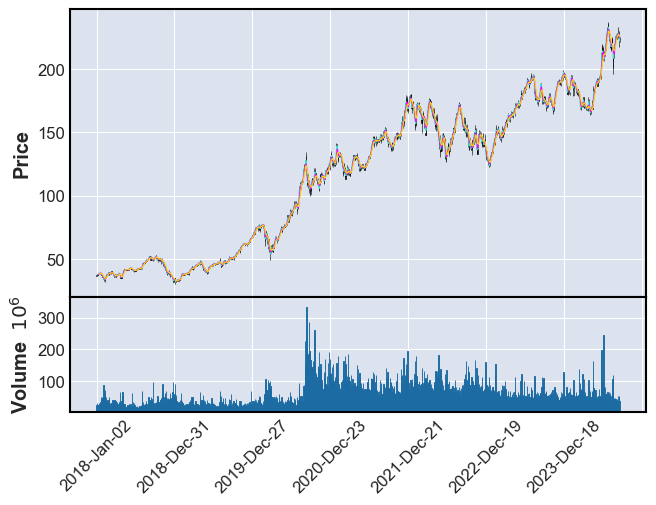

In [22]:
stock_us_daily_df = ak.stock_us_daily(symbol="AAPL", adjust="qfq")
stock_us_daily_df = stock_us_daily_df.set_index(["date"])
stock_us_daily_df = stock_us_daily_df[sd : ed]
mpf.plot(stock_us_daily_df, type="candle", mav=(3, 6, 9), volume=True, show_nontrading=False)